# 04 – FLAG3D Data Exploration

**Obiettivi:**
- Caricare il dataset FLAG3D
- Capire la struttura dei dati (forme, chiavi, label)
- Esplorare le annotazioni testuali (nome azione, descrizione, errori comuni, etc.)
- Analizzare lo split train/val esistente
- Creare statistiche e visualizzazioni

**Struttura FLAG3D:**
- `flag3d_keypoint.pkl` → contiene i keypoint skeleton (NTU-RGB+D format, 25 joint)
- `annotations/` → file di testo con descrizioni per ogni azione
  - `AxxxI001.txt` → nome dell'azione
  - `AxxxI002.txt` → descrizione dell'esecuzione
  - `AxxxI003.txt` → istruzioni sulla respirazione
  - `AxxxI004.txt` → punti chiave da ricordare
  - `AxxxI005.txt` → errori comuni e soluzioni
  - `AxxxI006.txt` → note aggiuntive

**Naming convention (da FLAG3D Instruction.txt):**
- `Mxxx` → avatar/modello numero xxx
- `Pxxx` → persona numero xxx
- `Axxx` → azione numero xxx
- `R` → numero di ripetizione della stessa azione

In [1]:
from pathlib import Path
import pickle
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Cartella root del progetto (un livello sopra "notebooks/")
ROOT_DIR = Path("..").resolve()

# Path dei dati FLAG3D
DATA_DIR = ROOT_DIR / "data" / "FLAG3D"
KEYPOINT_PATH = DATA_DIR / "flag3d_keypoint.pkl"
ANNOTATIONS_DIR = DATA_DIR / "annotations"

print("DATA_DIR:", DATA_DIR)
print("Keypoint file esiste?", KEYPOINT_PATH.exists())
print("Annotations dir esiste?", ANNOTATIONS_DIR.exists())

DATA_DIR: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/data/FLAG3D
Keypoint file esiste? True
Annotations dir esiste? True


## 1. Caricamento dei dati keypoint (pose)

In [2]:
with open(KEYPOINT_PATH, "rb") as f:
    data = pickle.load(f)

print("Tipo di data:", type(data))
print("Chiavi del dizionario:", list(data.keys()))

Tipo di data: <class 'dict'>
Chiavi del dizionario: ['split', 'annotations']


In [21]:
# Esploriamo la struttura
annotations = data['annotations']
split = data['split']

print("Chiavi split:", list(split.keys()))
print(f"Numero totale di sequenze: {len(annotations)}")
print(f"\nSplit:")
print(f"  - Train: {len(split['train'])} sequenze")
print(f"  - Val: {len(split['val'])} sequenze")


Chiavi split: ['train', 'val']
Numero totale di sequenze: 7200

Split:
  - Train: 5040 sequenze
  - Val: 2160 sequenze


In [4]:
# Esploriamo un singolo elemento
sample = annotations[0]
print("Chiavi di un'annotazione:", list(sample.keys()))
print()
print(f"frame_dir: {sample['frame_dir']}")
print(f"total_frames: {sample['total_frames']}")
print(f"label: {sample['label']}")
print(f"keypoint shape: {sample['keypoint'].shape}")
print(f"keypoint dtype: {sample['keypoint'].dtype}")

Chiavi di un'annotazione: ['keypoint', 'frame_dir', 'total_frames', 'label']

frame_dir: M001P002A001R001
total_frames: 1380
label: 0
keypoint shape: (1, 1380, 25, 3)
keypoint dtype: float32


### Struttura dei keypoint

I keypoint seguono il formato NTU-RGB+D con 25 joint:
- Shape: `(1, T, 25, 3)` dove:
  - 1 = numero di persone (sempre 1 in FLAG3D)
  - T = numero di frame (variabile)
  - 25 = numero di joint
  - 3 = coordinate (x, y, z)

In [5]:
# NTU-RGB+D 25 joint names
NTU_JOINT_NAMES = [
    "base_of_the_spine",       # 0
    "middle_of_the_spine",     # 1
    "neck",                    # 2
    "head",                    # 3
    "left_shoulder",           # 4
    "left_elbow",              # 5
    "left_wrist",              # 6
    "left_hand",               # 7
    "right_shoulder",          # 8
    "right_elbow",             # 9
    "right_wrist",             # 10
    "right_hand",              # 11
    "left_hip",                # 12
    "left_knee",               # 13
    "left_ankle",              # 14
    "left_foot",               # 15
    "right_hip",               # 16
    "right_knee",              # 17
    "right_ankle",             # 18
    "right_foot",              # 19
    "spine",                   # 20
    "tip_of_the_left_hand",    # 21
    "left_thumb",              # 22
    "tip_of_the_right_hand",   # 23
    "right_thumb",             # 24
]

print(f"Numero di joint: {len(NTU_JOINT_NAMES)}")

Numero di joint: 25


## 2. Parsing dei metadati dal frame_dir

Il `frame_dir` ha formato: `MxxxPxxxAxxxRxxx`
- M = Model/Avatar ID
- P = Person ID
- A = Action ID
- R = Repeat/Ripetizione

In [6]:
def parse_frame_dir(frame_dir):
    """Parse frame_dir to extract M, P, A, R identifiers."""
    pattern = r'M(\d+)P(\d+)A(\d+)R(\d+)'
    match = re.match(pattern, frame_dir)
    if match:
        return {
            'model_id': int(match.group(1)),
            'person_id': int(match.group(2)),
            'action_id': int(match.group(3)),
            'repeat_id': int(match.group(4)),
        }
    return None

# Test
test_fd = annotations[0]['frame_dir']
print(f"frame_dir: {test_fd}")
print(f"parsed: {parse_frame_dir(test_fd)}")

frame_dir: M001P002A001R001
parsed: {'model_id': 1, 'person_id': 2, 'action_id': 1, 'repeat_id': 1}


In [7]:
# Creiamo un DataFrame con tutti i metadati
records = []
for idx, ann in enumerate(annotations):
    parsed = parse_frame_dir(ann['frame_dir'])
    if parsed:
        records.append({
            'idx': idx,
            'frame_dir': ann['frame_dir'],
            'model_id': parsed['model_id'],
            'person_id': parsed['person_id'],
            'action_id': parsed['action_id'],
            'repeat_id': parsed['repeat_id'],
            'label': ann['label'],
            'total_frames': ann['total_frames'],
        })

df = pd.DataFrame(records)
print(f"DataFrame shape: {df.shape}")
df.head(10)

DataFrame shape: (7200, 8)


,idx,frame_dir,model_id,person_id,action_id,repeat_id,label,total_frames
0,0,M001P002A001R001,1,2,1,1,0,1380
1,1,M001P002A001R002,1,2,1,2,0,1147
2,2,M001P002A001R003,1,2,1,3,0,1284
3,3,M001P002A002R001,1,2,2,1,1,1401
4,4,M001P002A002R002,1,2,2,2,1,1232
5,5,M001P002A002R003,1,2,2,3,1,1249
6,6,M001P002A003R001,1,2,3,1,2,1239
7,7,M001P002A003R002,1,2,3,2,2,1186
8,8,M001P002A003R003,1,2,3,3,2,1424
9,9,M001P002A004R001,1,2,4,1,3,2415


In [8]:
# Verifichiamo che label == action_id - 1
df['label_check'] = df['action_id'] - 1
print("Label == action_id - 1?")
print((df['label'] == df['label_check']).all())
df.drop('label_check', axis=1, inplace=True)

Label == action_id - 1?
True


In [9]:
# Statistiche sui metadati
print("Statistiche FLAG3D:")
print(f"  - Numero totale sequenze: {len(df)}")
print(f"  - Modelli unici: {df['model_id'].nunique()} (range: {df['model_id'].min()}-{df['model_id'].max()})")
print(f"  - Persone uniche: {df['person_id'].nunique()} (range: {df['person_id'].min()}-{df['person_id'].max()})")
print(f"  - Azioni uniche: {df['action_id'].nunique()} (range: {df['action_id'].min()}-{df['action_id'].max()})")
print(f"  - Label uniche: {df['label'].nunique()} (range: {df['label'].min()}-{df['label'].max()})")
print(f"  - Frame totali: {df['total_frames'].sum():,}")
print(f"  - Frame per sequenza: min={df['total_frames'].min()}, max={df['total_frames'].max()}, mean={df['total_frames'].mean():.1f}")

Statistiche FLAG3D:
  - Numero totale sequenze: 7200
  - Modelli unici: 4 (range: 1-4)
  - Persone uniche: 10 (range: 1-10)
  - Azioni uniche: 60 (range: 1-60)
  - Label uniche: 60 (range: 0-59)
  - Frame totali: 5,895,200
  - Frame per sequenza: min=301, max=3089, mean=818.8


## 3. Caricamento delle annotazioni testuali

In [10]:
def load_annotation_text(action_id, info_type):
    """Load text annotation for an action.
    
    Args:
        action_id: int, 1-60
        info_type: int, 1-6
            1 = action name
            2 = description
            3 = breathing instructions
            4 = key points to remember
            5 = common mistakes and solutions
            6 = additional notes
    
    Returns:
        str or None if file doesn't exist
    """
    filename = f"A{action_id:03d}I{info_type:03d}.txt"
    filepath = ANNOTATIONS_DIR / filename
    if filepath.exists():
        with open(filepath, 'r') as f:
            return f.read().strip()
    return None

# Test
print("Esempio annotazione per A001 (Svend Press):")
print(f"  I001 (nome): {load_annotation_text(1, 1)}")
print(f"  I002 (descrizione): {load_annotation_text(1, 2)[:100]}...")
print(f"  I003 (respirazione): {load_annotation_text(1, 3)}")
print(f"  I005 (errori): {load_annotation_text(1, 5)}")

Esempio annotazione per A001 (Svend Press):
  I001 (nome): Svend Press
  I002 (descrizione): stand shoulder-width apart, tighten your abdominal muscles, clamp the barbell piece in front of the ...
  I003 (respirazione): inhale when restoring, and exhale when pushing.
  I005 (errori): mistake: use insufficient power to clamp the barbell piece.
solution: clamp the barbell piece in front of your chest firmly.


In [ ]:
# Carichiamo tutti i nomi delle azioni
action_names = {}
for aid in range(1, 61):
    name = load_annotation_text(aid, 1)
    if name:
        action_names[aid] = name

print(f"Caricate {len(action_names)} action names")
print("\nPrime 10 azioni:")
for aid in list(action_names.keys())[:10]:
    print(f"  A{aid:03d} (label {aid-1}): {action_names[aid]}")

Caricate 60 action names

Prime 10 azioni:
  A001 (label 0): Svend Press
  A002 (label 1): Kneeling Push-ups
  A003 (label 2): Standing Straight-arm Chest Press With Resistance Band
  A004 (label 3): Small Dumbbell Floor Flies
  A005 (label 4): Chest Fly
  A006 (label 5): Push-ups
  A007 (label 6): Bent-over W-shape Stretch
  A008 (label 7): Bent-over Y-shape Stretch
  A009 (label 8): Bent-over A-shape Stretch
  A010 (label 9): Squat With Arm Lift
  A011 (label 10): Breaststroke Arm Pull
  A012 (label 11): Prone Y-shape Stretch
  A013 (label 12): Lateral Raise Forward Circles
  A014 (label 13): Lateral Raise Backward Circles
  A015 (label 14): Lying Shoulder Joint Upward Round
  A016 (label 15): Lying Shoulder Joint Downward Round
  A017 (label 16): Bare-handed Full Lateral Raise
  A018 (label 17): Bare-handed Cuban Press
  A019 (label 18): Fortune Cat
  A020 (label 19): Dumbbell Curls
  A021 (label 20): Alternate Dumbbell Curls
  A022 (label 21): Right-side Kettlebell Bent-over Row
  

In [12]:
# Aggiungiamo i nomi delle azioni al DataFrame
df['action_name'] = df['action_id'].map(action_names)
df.head()

,idx,frame_dir,model_id,person_id,action_id,repeat_id,label,total_frames,action_name
0,0,M001P002A001R001,1,2,1,1,0,1380,Svend Press
1,1,M001P002A001R002,1,2,1,2,0,1147,Svend Press
2,2,M001P002A001R003,1,2,1,3,0,1284,Svend Press
3,3,M001P002A002R001,1,2,2,1,1,1401,Kneeling Push-ups
4,4,M001P002A002R002,1,2,2,2,1,1232,Kneeling Push-ups


In [13]:
# Carichiamo tutte le annotazioni per ogni azione
INFO_TYPES = {
    1: 'name',
    2: 'description',
    3: 'breathing',
    4: 'key_points',
    5: 'mistakes',
    6: 'notes'
}

all_annotations = {}
for aid in range(1, 61):
    all_annotations[aid] = {}
    for itype, iname in INFO_TYPES.items():
        text = load_annotation_text(aid, itype)
        if text:
            all_annotations[aid][iname] = text

# Statistiche sulle annotazioni disponibili
print("Disponibilità annotazioni per tipo:")
for iname in INFO_TYPES.values():
    count = sum(1 for a in all_annotations.values() if iname in a)
    print(f"  {iname}: {count}/60 azioni")

Disponibilità annotazioni per tipo:
  name: 60/60 azioni
  description: 60/60 azioni
  breathing: 60/60 azioni
  key_points: 60/60 azioni
  mistakes: 60/60 azioni
  notes: 54/60 azioni


In [14]:
# Esempio completo di annotazioni per un'azione
example_action = 10  # Squat With Arm Lift
print(f"=== Annotazioni complete per A{example_action:03d} ===")
for iname, text in all_annotations[example_action].items():
    print(f"\n[{iname.upper()}]")
    print(text)

=== Annotazioni complete per A010 ===

[NAME]
Squat With Arm Lift

[DESCRIPTION]
squat down entirely and relax your legs. lift one arm and stretch it upward with force, move your gaze with your hand until you straighten them up, and then restore it after a short pause. keep the other arm against the inside of the knee to prevent the lower limb from following the upper body, and then exchange hands in turn.

[BREATHING]
inhale when lifting the arm, and exhale when restoring.

[KEY_POINTS]
the thoracic spine twists to a certain extent, and the chest on the hand-raising side feels slightly pulled.

[MISTAKES]
mistake: lower limbs follow upper limbs to turn.
solution: keep the other arm against the inside of the knee to prevent the lower limb from following the upper body rotation.

[NOTES]
squat entirely and relax your legs.
keep your waist and back straight.
keep your arms in front of your knees.


## 4. Distribuzione delle azioni

In [15]:
# Conteggio sequenze per azione
action_counts = df.groupby(['action_id', 'action_name']).size().reset_index(name='count')
action_counts = action_counts.sort_values('action_id')
print("Sequenze per azione:")
print(action_counts.to_string())

Sequenze per azione:
    action_id                                                 action_name  count
0           1                                                 Svend Press    120
1           2                                           Kneeling Push-ups    120
2           3      Standing Straight-arm Chest Press With Resistance Band    120
3           4                                  Small Dumbbell Floor Flies    120
4           5                                                   Chest Fly    120
5           6                                                    Push-ups    120
6           7                                   Bent-over W-shape Stretch    120
7           8                                   Bent-over Y-shape Stretch    120
8           9                                   Bent-over A-shape Stretch    120
9          10                                         Squat With Arm Lift    120
10         11                                       Breaststroke Arm Pull    120
11     

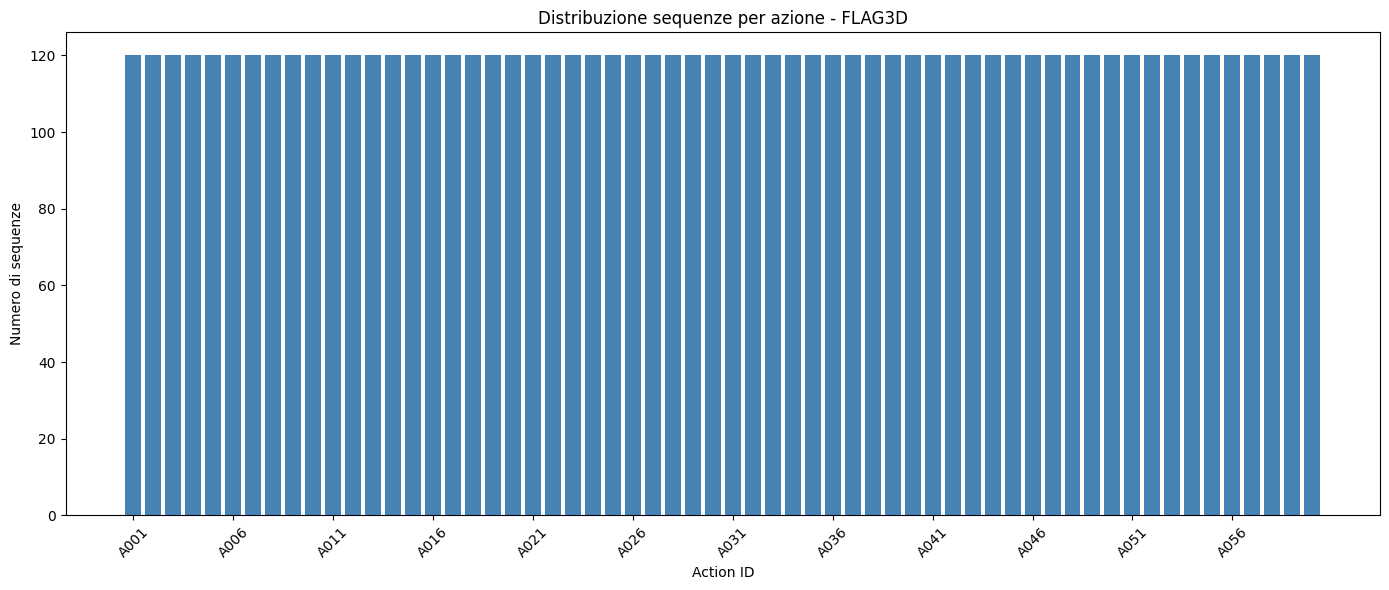


Sequenze per azione: min=120, max=120, mean=120.0


In [16]:
# Plot distribuzione azioni
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(action_counts)), action_counts['count'], color='steelblue')
ax.set_xlabel('Action ID')
ax.set_ylabel('Numero di sequenze')
ax.set_title('Distribuzione sequenze per azione - FLAG3D')
ax.set_xticks(range(0, len(action_counts), 5))
ax.set_xticklabels([f'A{i:03d}' for i in range(1, 61, 5)], rotation=45)
plt.tight_layout()
plt.show()

print(f"\nSequenze per azione: min={action_counts['count'].min()}, max={action_counts['count'].max()}, mean={action_counts['count'].mean():.1f}")

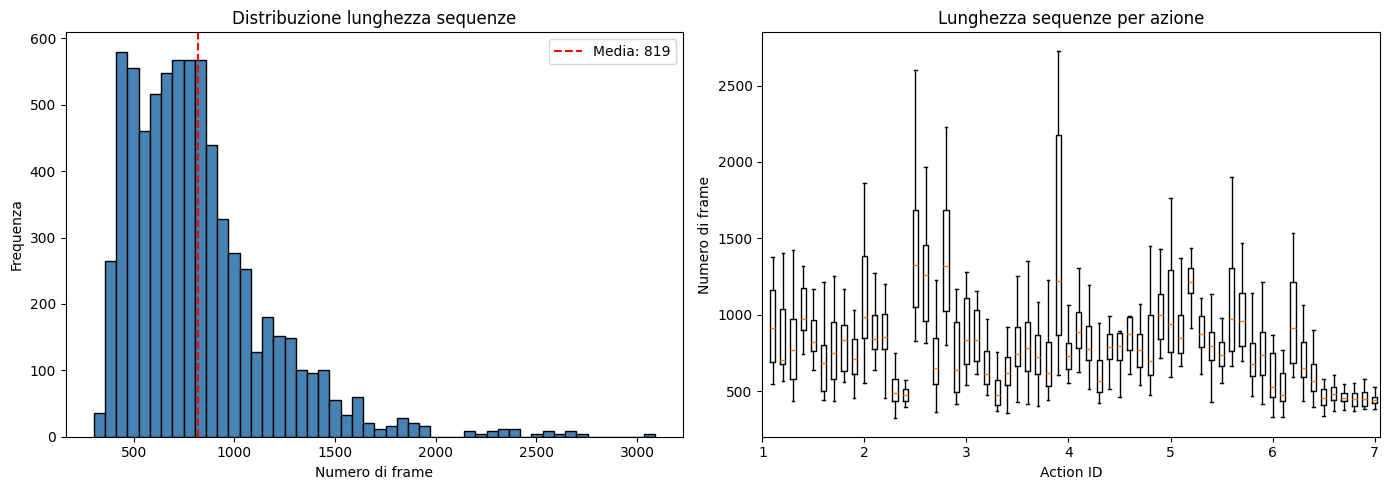

In [17]:
# Distribuzione frame per sequenza
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Istogramma
axes[0].hist(df['total_frames'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Numero di frame')
axes[0].set_ylabel('Frequenza')
axes[0].set_title('Distribuzione lunghezza sequenze')
axes[0].axvline(df['total_frames'].mean(), color='red', linestyle='--', label=f'Media: {df["total_frames"].mean():.0f}')
axes[0].legend()

# Box plot per azione
frame_by_action = [df[df['action_id'] == aid]['total_frames'].values for aid in range(1, 61)]
axes[1].boxplot(frame_by_action, showfliers=False)
axes[1].set_xlabel('Action ID')
axes[1].set_ylabel('Numero di frame')
axes[1].set_title('Lunghezza sequenze per azione')
axes[1].set_xticks(range(0, 61, 10))

plt.tight_layout()
plt.show()

## 5. Analisi split Train/Val

In [18]:
# Lo split usa identificatori nel formato S002C002M001P002A001R001
# Dobbiamo matchare con il nostro frame_dir
print("Esempio split train:", split['train'][:3])
print("Esempio frame_dir:", df['frame_dir'].iloc[0])

# Il frame_dir è la parte finale dell'identificatore split
# Split format: SxxxCxxxMxxxPxxxAxxxRxxx
# frame_dir: MxxxPxxxAxxxRxxx

def extract_frame_dir_from_split(split_id):
    """Extract the MxxxPxxxAxxxRxxx part from split identifier."""
    pattern = r'(M\d+P\d+A\d+R\d+)'
    match = re.search(pattern, split_id)
    if match:
        return match.group(1)
    return None

# Creiamo set di frame_dir per train e val
train_frame_dirs = set(extract_frame_dir_from_split(s) for s in split['train'])
val_frame_dirs = set(extract_frame_dir_from_split(s) for s in split['val'])

print(f"\nTrain unique frame_dirs: {len(train_frame_dirs)}")
print(f"Val unique frame_dirs: {len(val_frame_dirs)}")

Esempio split train: ['S002C002M001P002A001R001', 'S002C002M001P002A001R002', 'S002C002M001P002A001R003']
Esempio frame_dir: M001P002A001R001

Train unique frame_dirs: 5040
Val unique frame_dirs: 2160


In [19]:
# Assegniamo lo split al DataFrame
def get_split(frame_dir):
    if frame_dir in train_frame_dirs:
        return 'train'
    elif frame_dir in val_frame_dirs:
        return 'val'
    return 'unknown'

df['split'] = df['frame_dir'].apply(get_split)
print("Distribuzione split:")
print(df['split'].value_counts())

Distribuzione split:
split
train    5040
val      2160
Name: count, dtype: int64


In [20]:
# Distribuzione per azione in train/val
split_by_action = df.groupby(['action_id', 'action_name', 'split']).size().unstack(fill_value=0)
print("Sequenze per azione e split:")
print(split_by_action.head(20))

Sequenze per azione e split:
split                                                         train  val
action_id action_name                                                   
1         Svend Press                                            84   36
2         Kneeling Push-ups                                      84   36
3         Standing Straight-arm Chest Press With Resistan...     84   36
4         Small Dumbbell Floor Flies                             84   36
5         Chest Fly                                              84   36
6         Push-ups                                               84   36
7         Bent-over W-shape Stretch                              84   36
8         Bent-over Y-shape Stretch                              84   36
9         Bent-over A-shape Stretch                              84   36
10        Squat With Arm Lift                                    84   36
11        Breaststroke Arm Pull                                  84   36
12        Prone Y-shap

/Users/giovanniconter/Desktop/pose-text-feedback-thesis/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


TypeError: only length-1 arrays can be converted to Python scalars

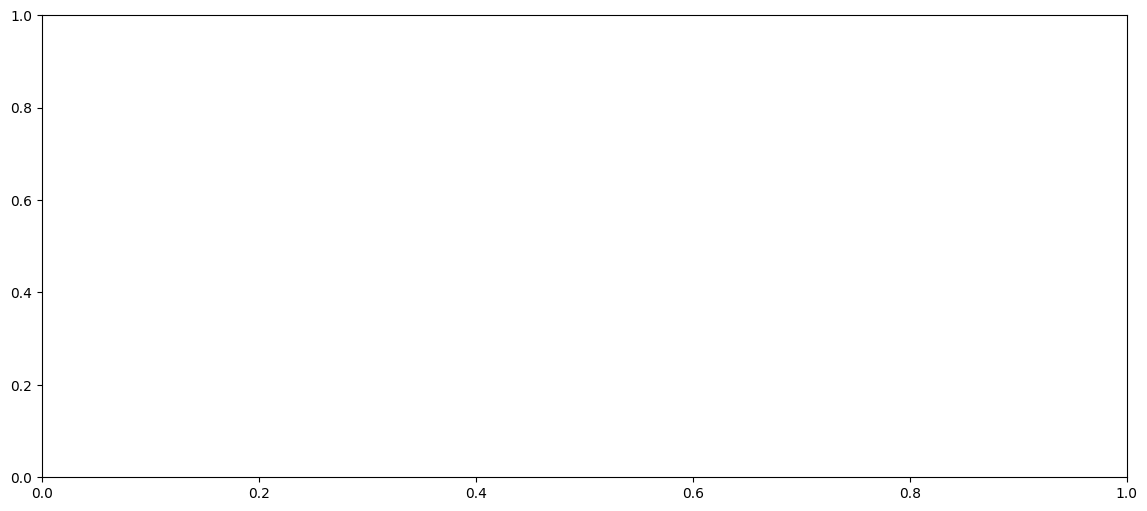

In [21]:
# Visualizzazione split per azione
# Prima creiamo un DataFrame semplice con solo action_id e split
split_counts = df.groupby(['action_id', 'split']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(60)
width = 0.35

# Estrai i conteggi train e val per ogni action_id (1-60)
train_counts = [int(split_counts.loc[i+1, 'train']) if i+1 in split_counts.index and 'train' in split_counts.columns else 0 for i in range(60)]
val_counts = [int(split_counts.loc[i+1, 'val']) if i+1 in split_counts.index and 'val' in split_counts.columns else 0 for i in range(60)]

ax.bar(x - width/2, train_counts, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts, width, label='Val', color='coral')

ax.set_xlabel('Action ID')
ax.set_ylabel('Numero di sequenze')
ax.set_title('Distribuzione Train/Val per azione - FLAG3D')
ax.set_xticks(range(0, 60, 5))
ax.set_xticklabels([f'A{i+1:03d}' for i in range(0, 60, 5)], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Rapporto train/val
train_total = df[df['split'] == 'train'].shape[0]
val_total = df[df['split'] == 'val'].shape[0]
print(f"\nRapporto Train/Val: {train_total}/{val_total} = {train_total/val_total:.2f}")

### Analisi split per persona/modello

In [ ]:
# Distribuzione per persona
print("Sequenze per persona:")
print(df.groupby(['person_id', 'split']).size().unstack(fill_value=0))

print("\nSequenze per modello:")
print(df.groupby(['model_id', 'split']).size().unstack(fill_value=0))

## 6. Visualizzazione dei keypoint

In [ ]:
# NTU-RGB+D skeleton connections
NTU_CONNECTIONS = [
    (0, 1), (1, 20), (20, 2), (2, 3),  # spine to head
    (20, 4), (4, 5), (5, 6), (6, 7), (7, 21), (7, 22),  # left arm
    (20, 8), (8, 9), (9, 10), (10, 11), (11, 23), (11, 24),  # right arm
    (0, 12), (12, 13), (13, 14), (14, 15),  # left leg
    (0, 16), (16, 17), (17, 18), (18, 19),  # right leg
]

def plot_skeleton_frame(keypoints, frame_idx=0, title="Skeleton"):
    """Plot a single skeleton frame.
    
    Args:
        keypoints: array of shape (1, T, 25, 3)
        frame_idx: which frame to plot
        title: plot title
    """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Get frame
    frame = keypoints[0, frame_idx]  # (25, 3)
    
    # Plot joints
    ax.scatter(frame[:, 0], frame[:, 1], frame[:, 2], c='blue', s=50)
    
    # Plot connections
    for i, j in NTU_CONNECTIONS:
        ax.plot([frame[i, 0], frame[j, 0]],
                [frame[i, 1], frame[j, 1]],
                [frame[i, 2], frame[j, 2]], 'b-', linewidth=2)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    # Equal aspect ratio
    max_range = np.array([frame[:, 0].max() - frame[:, 0].min(),
                          frame[:, 1].max() - frame[:, 1].min(),
                          frame[:, 2].max() - frame[:, 2].min()]).max() / 2.0
    mid_x = (frame[:, 0].max() + frame[:, 0].min()) * 0.5
    mid_y = (frame[:, 1].max() + frame[:, 1].min()) * 0.5
    mid_z = (frame[:, 2].max() + frame[:, 2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.tight_layout()
    return fig

In [ ]:
# Visualizziamo un esempio per azione
# Scegliamo alcune azioni rappresentative
example_actions = [1, 10, 20, 30, 40, 50]  # Diverse azioni

fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for i, aid in enumerate(example_actions):
    # Trova prima sequenza di questa azione
    idx = df[df['action_id'] == aid].iloc[0]['idx']
    sample = annotations[idx]
    keypoints = sample['keypoint']
    
    # Plot middle frame
    mid_frame = keypoints.shape[1] // 2
    frame = keypoints[0, mid_frame]
    
    ax = axes[i]
    ax.scatter(frame[:, 0], frame[:, 1], frame[:, 2], c='blue', s=30)
    for j, k in NTU_CONNECTIONS:
        ax.plot([frame[j, 0], frame[k, 0]],
                [frame[j, 1], frame[k, 1]],
                [frame[j, 2], frame[k, 2]], 'b-', linewidth=1.5)
    
    ax.set_title(f'A{aid:03d}: {action_names.get(aid, "Unknown")[:20]}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.tight_layout()
plt.show()

## 7. Riepilogo e confronto con EC3D

In [ ]:
print("=" * 60)
print("RIEPILOGO FLAG3D")
print("=" * 60)
print(f"\n📊 STATISTICHE GENERALI")
print(f"   - Numero totale sequenze: {len(df)}")
print(f"   - Numero azioni (classi): {df['action_id'].nunique()}")
print(f"   - Numero modelli: {df['model_id'].nunique()}")
print(f"   - Numero persone: {df['person_id'].nunique()}")
print(f"   - Frame totali: {df['total_frames'].sum():,}")

print(f"\n📏 LUNGHEZZA SEQUENZE")
print(f"   - Min: {df['total_frames'].min()} frame")
print(f"   - Max: {df['total_frames'].max()} frame")
print(f"   - Media: {df['total_frames'].mean():.1f} frame")
print(f"   - Std: {df['total_frames'].std():.1f} frame")

print(f"\n🔀 SPLIT TRAIN/VAL")
print(f"   - Train: {(df['split'] == 'train').sum()} sequenze ({(df['split'] == 'train').sum() / len(df) * 100:.1f}%)")
print(f"   - Val: {(df['split'] == 'val').sum()} sequenze ({(df['split'] == 'val').sum() / len(df) * 100:.1f}%)")

print(f"\n🦴 STRUTTURA SKELETON")
print(f"   - Formato: NTU-RGB+D")
print(f"   - Numero joint: 25")
print(f"   - Coordinate: 3D (x, y, z)")
print(f"   - Shape keypoint: (1, T, 25, 3)")

print(f"\n📝 ANNOTAZIONI TESTUALI")
for iname in INFO_TYPES.values():
    count = sum(1 for a in all_annotations.values() if iname in a)
    print(f"   - {iname}: {count}/60 azioni")

In [ ]:
print("\n" + "=" * 60)
print("CONFRONTO FLAG3D vs EC3D")
print("=" * 60)

comparison = pd.DataFrame({
    'Caratteristica': [
        'Numero sequenze',
        'Numero classi',
        'Numero soggetti',
        'Frame totali',
        'Frame/sequenza (media)',
        'Numero joint',
        'Tipo esercizi',
        'Annotazioni testuali',
        'Split'
    ],
    'EC3D': [
        '371',
        '12 (3 esercizi × ~4 varianti)',
        '4',
        '29,789',
        '~80',
        '25',
        'Fitness (Squat, Lunges, Plank)',
        'No (solo label errori)',
        'Cross-subject'
    ],
    'FLAG3D': [
        f'{len(df)}',
        f'{df["action_id"].nunique()} (60 azioni fitness)',
        f'{df["person_id"].nunique()}',
        f'{df["total_frames"].sum():,}',
        f'{df["total_frames"].mean():.0f}',
        '25',
        'Fitness (60 esercizi diversi)',
        'Sì (descrizioni, errori, etc.)',
        'Train/Val (70/30)'
    ]
})

print(comparison.to_string(index=False))

## 8. Salvataggio dati processati

In [ ]:
# Salviamo i metadati e le annotazioni in un formato più accessibile
import json

# 1. Salva DataFrame dei metadati
df.to_csv(DATA_DIR / 'flag3d_metadata.csv', index=False)
print(f"✅ Salvato: {DATA_DIR / 'flag3d_metadata.csv'}")

# 2. Salva annotazioni testuali in JSON
annotations_json = {
    str(aid): {
        'action_id': aid,
        'label': aid - 1,
        **annot
    }
    for aid, annot in all_annotations.items()
}

with open(DATA_DIR / 'flag3d_annotations.json', 'w') as f:
    json.dump(annotations_json, f, indent=2)
print(f"✅ Salvato: {DATA_DIR / 'flag3d_annotations.json'}")

# 3. Salva mapping label -> nome azione
label_to_name = {aid - 1: name for aid, name in action_names.items()}
with open(DATA_DIR / 'flag3d_label_names.json', 'w') as f:
    json.dump(label_to_name, f, indent=2)
print(f"✅ Salvato: {DATA_DIR / 'flag3d_label_names.json'}")

In [ ]:
# 4. Salva split con indici del DataFrame
train_indices = df[df['split'] == 'train']['idx'].tolist()
val_indices = df[df['split'] == 'val']['idx'].tolist()

split_data = {
    'train_indices': train_indices,
    'val_indices': val_indices,
    'train_count': len(train_indices),
    'val_count': len(val_indices),
}

with open(DATA_DIR / 'flag3d_split.json', 'w') as f:
    json.dump(split_data, f, indent=2)
print(f"✅ Salvato: {DATA_DIR / 'flag3d_split.json'}")

## ✅ Riepilogo finale

Completata l'esplorazione del dataset FLAG3D:

1. **Caricato** `flag3d_keypoint.pkl` (7200 sequenze, 25 joint NTU-RGB+D)
2. **Estratto** metadati da `frame_dir`: model_id, person_id, action_id, repeat_id
3. **Caricato** annotazioni testuali per 60 azioni:
   - Nome azione
   - Descrizione esecuzione
   - Istruzioni respirazione
   - Punti chiave
   - Errori comuni e soluzioni
4. **Analizzato** split train/val esistente (70/30)
5. **Salvato** file processati:
   - `flag3d_metadata.csv` → metadati per ogni sequenza
   - `flag3d_annotations.json` → annotazioni testuali
   - `flag3d_label_names.json` → mapping label → nome azione
   - `flag3d_split.json` → indici train/val

**Differenze principali con EC3D:**
- FLAG3D ha 60 classi (azioni fitness diverse) vs 12 classi (varianti correct/error di 3 esercizi)
- FLAG3D include annotazioni testuali dettagliate per ogni azione
- FLAG3D ha molte più sequenze (7200 vs 371)
- FLAG3D non ha label "errore" esplicite, ma descrizioni di errori comuni nelle annotazioni

**Prossimi passi:**
- Utilizzare le annotazioni testuali per contrastive learning
- Adattare i modelli EC3D per FLAG3D
- Esplorare generazione di feedback usando le descrizioni